In [5]:
"""
================================================================================================
NOTEBOOK 01: Data Engineering, Labeling & Exploratory Data Analysis (EDA)
================================================================================================
Author: Mary Wangoi Mwangi (122174)
================================================================================================
Goal:
    Perform initial data engineering, labeling, and exploratory data analysis (EDA)
    on the Road Traffic Accident (RTA) Dataset.

Key Actions:
    1. Load and inspect the raw RTA dataset to understand its structure and variables
    2. Engineer the target variable (y) — Fatal vs. Non-Fatal
    3. Clean the data and handle missing values
    4. Conduct EDA to understand class distribution and identify high-impact predictors

Outcome:
    A cleaned, labeled dataset saved as 'rta_accidents_labeled.csv' in
    data/processed/ ready for model training in Notebook 02.
================================================================================================
"""

# ============================================================
# SECTION 1: LIBRARY IMPORTS & GLOBAL CONFIGURATION
# Load all required libraries and set consistent plot styling
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

# Consistent plot styling for thesis-quality visuals
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded successfully.")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
print(f"   seaborn : {sns.__version__}")

Libraries loaded successfully.
   pandas  : 2.3.3
   numpy   : 2.4.3
   seaborn : 0.13.2


In [6]:
# ============================================================
# SECTION 2: DATA LOADING & INITIAL INSPECTION
# Loading the raw RTA dataset and inspecting its structure
# ============================================================

# Load the raw dataset
data_path = '../data/raw/rta_raw.csv'

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")
print(f"\n{'='*50}")
print("COLUMN NAMES:")
print(f"{'='*50}")
for col in df.columns.tolist():
    print(f"   - {col}")

print(f"\n{'='*50}")
print("DATA TYPES:")
print(f"{'='*50}")
print(df.dtypes)

print(f"\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully.
   Rows    : 12,316
   Columns : 32

COLUMN NAMES:
   - Time
   - Day_of_week
   - Age_band_of_driver
   - Sex_of_driver
   - Educational_level
   - Vehicle_driver_relation
   - Driving_experience
   - Type_of_vehicle
   - Owner_of_vehicle
   - Service_year_of_vehicle
   - Defect_of_vehicle
   - Area_accident_occured
   - Lanes_or_Medians
   - Road_allignment
   - Types_of_Junction
   - Road_surface_type
   - Road_surface_conditions
   - Light_conditions
   - Weather_conditions
   - Type_of_collision
   - Number_of_vehicles_involved
   - Number_of_casualties
   - Vehicle_movement
   - Casualty_class
   - Sex_of_casualty
   - Age_band_of_casualty
   - Casualty_severity
   - Work_of_casuality
   - Fitness_of_casuality
   - Pedestrian_movement
   - Cause_of_accident
   - Accident_severity

DATA TYPES:
Time                           object
Day_of_week                    object
Age_band_of_driver             object
Sex_of_driver                  object
Education

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [7]:
# ============================================================
# SECTION 3: TARGET VARIABLE INSPECTION
# Examine the unique values in our label column
# ============================================================

print("Unique values in Accident_severity:")
print(df['Accident_severity'].value_counts())
print(f"\nTotal missing values: {df['Accident_severity'].isna().sum()}")

Unique values in Accident_severity:
Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64

Total missing values: 0


In [8]:
# ============================================================
# SECTION 4: TARGET VARIABLE ENGINEERING
# Map Accident_severity to binary Severity_Class
# High-Severity (1): Fatal Injury + Serious Injury
# Low-Severity  (0): Slight Injury
# ============================================================

# Create binary target variable
df['Severity_Class'] = df['Accident_severity'].apply(
    lambda x: 1 if x in ['Fatal injury', 'Serious Injury'] else 0
)

# Verify the mapping
print("Severity_Class distribution:")
print(df['Severity_Class'].value_counts())
print(f"\nClass balance:")
print(f"   High-Severity (1) : {df['Severity_Class'].sum():,} ({df['Severity_Class'].mean()*100:.1f}%)")
print(f"   Low-Severity  (0) : {(df['Severity_Class']==0).sum():,} ({(1-df['Severity_Class'].mean())*100:.1f}%)")
print(f"\nImbalance ratio     : {(df['Severity_Class']==0).sum() / df['Severity_Class'].sum():.1f}:1")

Severity_Class distribution:
Severity_Class
0    10415
1     1901
Name: count, dtype: int64

Class balance:
   High-Severity (1) : 1,901 (15.4%)
   Low-Severity  (0) : 10,415 (84.6%)

Imbalance ratio     : 5.5:1


In [9]:
# ============================================================
# SECTION 5: MISSING VALUES ANALYSIS
# Identify columns with missing values and their extent
# ============================================================

# Calculate missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

# Show only columns with missing values
missing_df = missing_df[missing_df['Missing Count'] > 0]

print(f"Columns with missing values: {len(missing_df)}")
print(f"{'='*45}")
print(missing_df.to_string())
print(f"\nTotal missing values across dataset: {df.isnull().sum().sum():,}")

Columns with missing values: 16
                         Missing Count  Missing %
Defect_of_vehicle                 4427      35.95
Service_year_of_vehicle           3928      31.89
Work_of_casuality                 3198      25.97
Fitness_of_casuality              2635      21.39
Type_of_vehicle                    950       7.71
Types_of_Junction                  887       7.20
Driving_experience                 829       6.73
Educational_level                  741       6.02
Vehicle_driver_relation            579       4.70
Owner_of_vehicle                   482       3.91
Lanes_or_Medians                   385       3.13
Vehicle_movement                   308       2.50
Area_accident_occured              239       1.94
Road_surface_type                  172       1.40
Type_of_collision                  155       1.26
Road_allignment                    142       1.15

Total missing values across dataset: 20,057


In [10]:
# ============================================================
# SECTION 6: DATA CLEANING
# Handle missing values across all columns
# Categorical columns: fill with 'Unknown'
# ============================================================

# Identify categorical columns with missing values
cat_cols_with_missing = df.select_dtypes(include='object').columns[
    df.select_dtypes(include='object').isnull().any()
].tolist()

print(f"Categorical columns to impute: {len(cat_cols_with_missing)}")

# Fill missing values with 'Unknown'
df[cat_cols_with_missing] = df[cat_cols_with_missing].fillna('Unknown')

# Verify no missing values remain
remaining_missing = df.isnull().sum().sum()
print(f"\nMissing values after cleaning: {remaining_missing}")
print(f"\nCleaning complete.")
print(f"   Strategy : Fill categorical missing values with 'Unknown'")
print(f"   Columns imputed : {len(cat_cols_with_missing)}")
print(f"   Columns affected: {cat_cols_with_missing}")

Categorical columns to impute: 16

Missing values after cleaning: 0

Cleaning complete.
   Strategy : Fill categorical missing values with 'Unknown'
   Columns imputed : 16
   Columns affected: ['Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Type_of_collision', 'Vehicle_movement', 'Work_of_casuality', 'Fitness_of_casuality']


In [11]:
# ============================================================
# SECTION 7: POST-CLEANING SANITY CHECK
# Verify dataset integrity after cleaning
# ============================================================

print(f"Dataset shape after cleaning: {df.shape}")
print(f"Missing values remaining    : {df.isnull().sum().sum()}")
print(f"Target variable intact      : {df['Severity_Class'].value_counts().to_dict()}")

print(f"\n{'='*50}")
print("UNIQUE VALUES IN KEY FEATURE COLUMNS:")
print(f"{'='*50}")

key_cols = [
    'Type_of_vehicle',
    'Type_of_collision', 
    'Cause_of_accident',
    'Age_band_of_driver',
    'Driving_experience',
    'Road_surface_conditions',
    'Light_conditions',
    'Weather_conditions'
]

for col in key_cols:
    print(f"\n{col}:")
    for val in df[col].unique():
        print(f"   - {val}")

Dataset shape after cleaning: (12316, 33)
Missing values remaining    : 0
Target variable intact      : {0: 10415, 1: 1901}

UNIQUE VALUES IN KEY FEATURE COLUMNS:

Type_of_vehicle:
   - Automobile
   - Public (> 45 seats)
   - Lorry (41?100Q)
   - Unknown
   - Public (13?45 seats)
   - Lorry (11?40Q)
   - Long lorry
   - Public (12 seats)
   - Taxi
   - Pick up upto 10Q
   - Stationwagen
   - Ridden horse
   - Other
   - Bajaj
   - Turbo
   - Motorcycle
   - Special vehicle
   - Bicycle

Type_of_collision:
   - Collision with roadside-parked vehicles
   - Vehicle with vehicle collision
   - Collision with roadside objects
   - Collision with animals
   - Other
   - Rollover
   - Fall from vehicles
   - Collision with pedestrians
   - With Train
   - Unknown

Cause_of_accident:
   - Moving Backward
   - Overtaking
   - Changing lane to the left
   - Changing lane to the right
   - Overloading
   - Other
   - No priority to vehicle
   - No priority to pedestrian
   - No distancing
   - G

In [12]:
# ============================================================
# SECTION 8: DATA STANDARDIZATION
# Standardize categorical values to ensure consistency
# Strip whitespace and fix inconsistent casing
# ============================================================

# Get all categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Strip whitespace and standardize 'unknown' variations to 'Unknown'
for col in cat_cols:
    df[col] = df[col].str.strip()
    df[col] = df[col].replace({
        'unknown': 'Unknown',
        'UNKNOWN': 'Unknown',
        'nan': 'Unknown'
    })

# Verify fix on Driving_experience
print("Driving_experience unique values after standardization:")
for val in sorted(df['Driving_experience'].unique()):
    print(f"   - {val}")

print(f"\nStandardization complete across {len(cat_cols)} categorical columns.")

Driving_experience unique values after standardization:
   - 1-2yr
   - 2-5yr
   - 5-10yr
   - Above 10yr
   - Below 1yr
   - No Licence
   - Unknown

Standardization complete across 30 categorical columns.


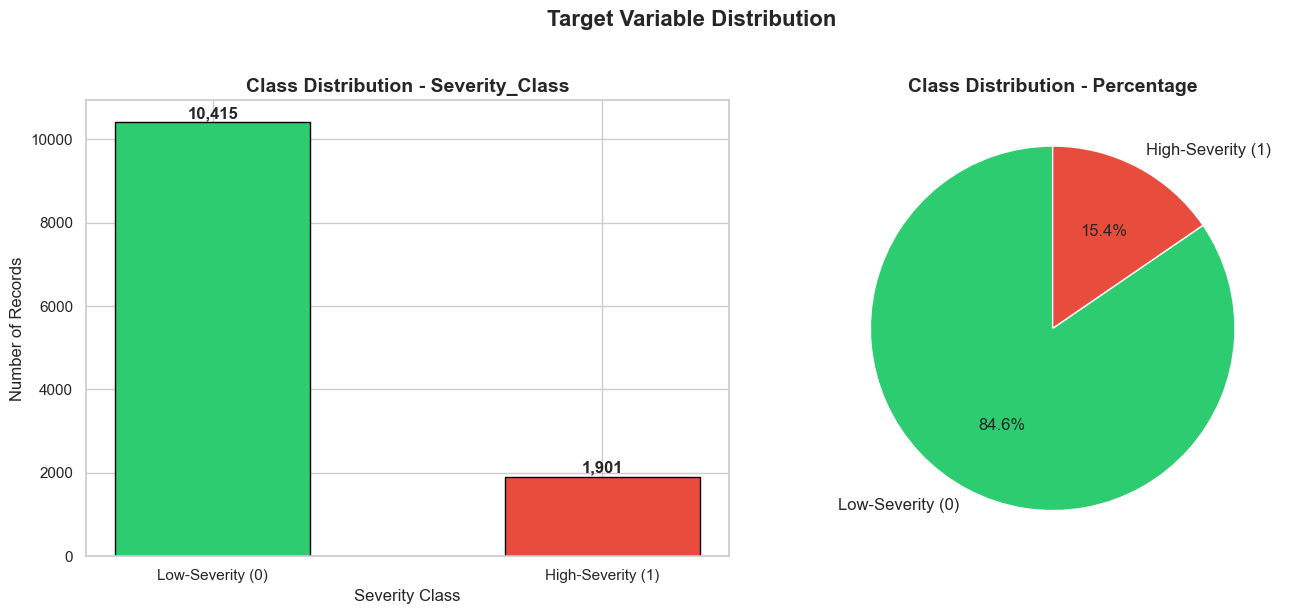

Low-Severity  (0): 10,415 (84.6%)
High-Severity (1): 1,901 (15.4%)
Imbalance ratio  : 5.5:1


In [14]:
# ============================================================
# SECTION 9: EDA - CLASS DISTRIBUTION
# Visualize the distribution of the target variable
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Count plot ---
colors = ['#2ecc71', '#e74c3c']
labels = ['Low-Severity (0)', 'High-Severity (1)']
counts = df['Severity_Class'].value_counts().sort_index()

axes[0].bar(labels, counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution - Severity_Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Severity Class', fontsize=12)
axes[0].set_ylabel('Number of Records', fontsize=12)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=12, fontweight='bold')

# --- Plot 2: Pie chart ---
axes[1].pie(
    counts.values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)
axes[1].set_title('Class Distribution - Percentage', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Low-Severity  (0): {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)")
print(f"High-Severity (1): {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)")
print(f"Imbalance ratio  : {counts[0]/counts[1]:.1f}:1")

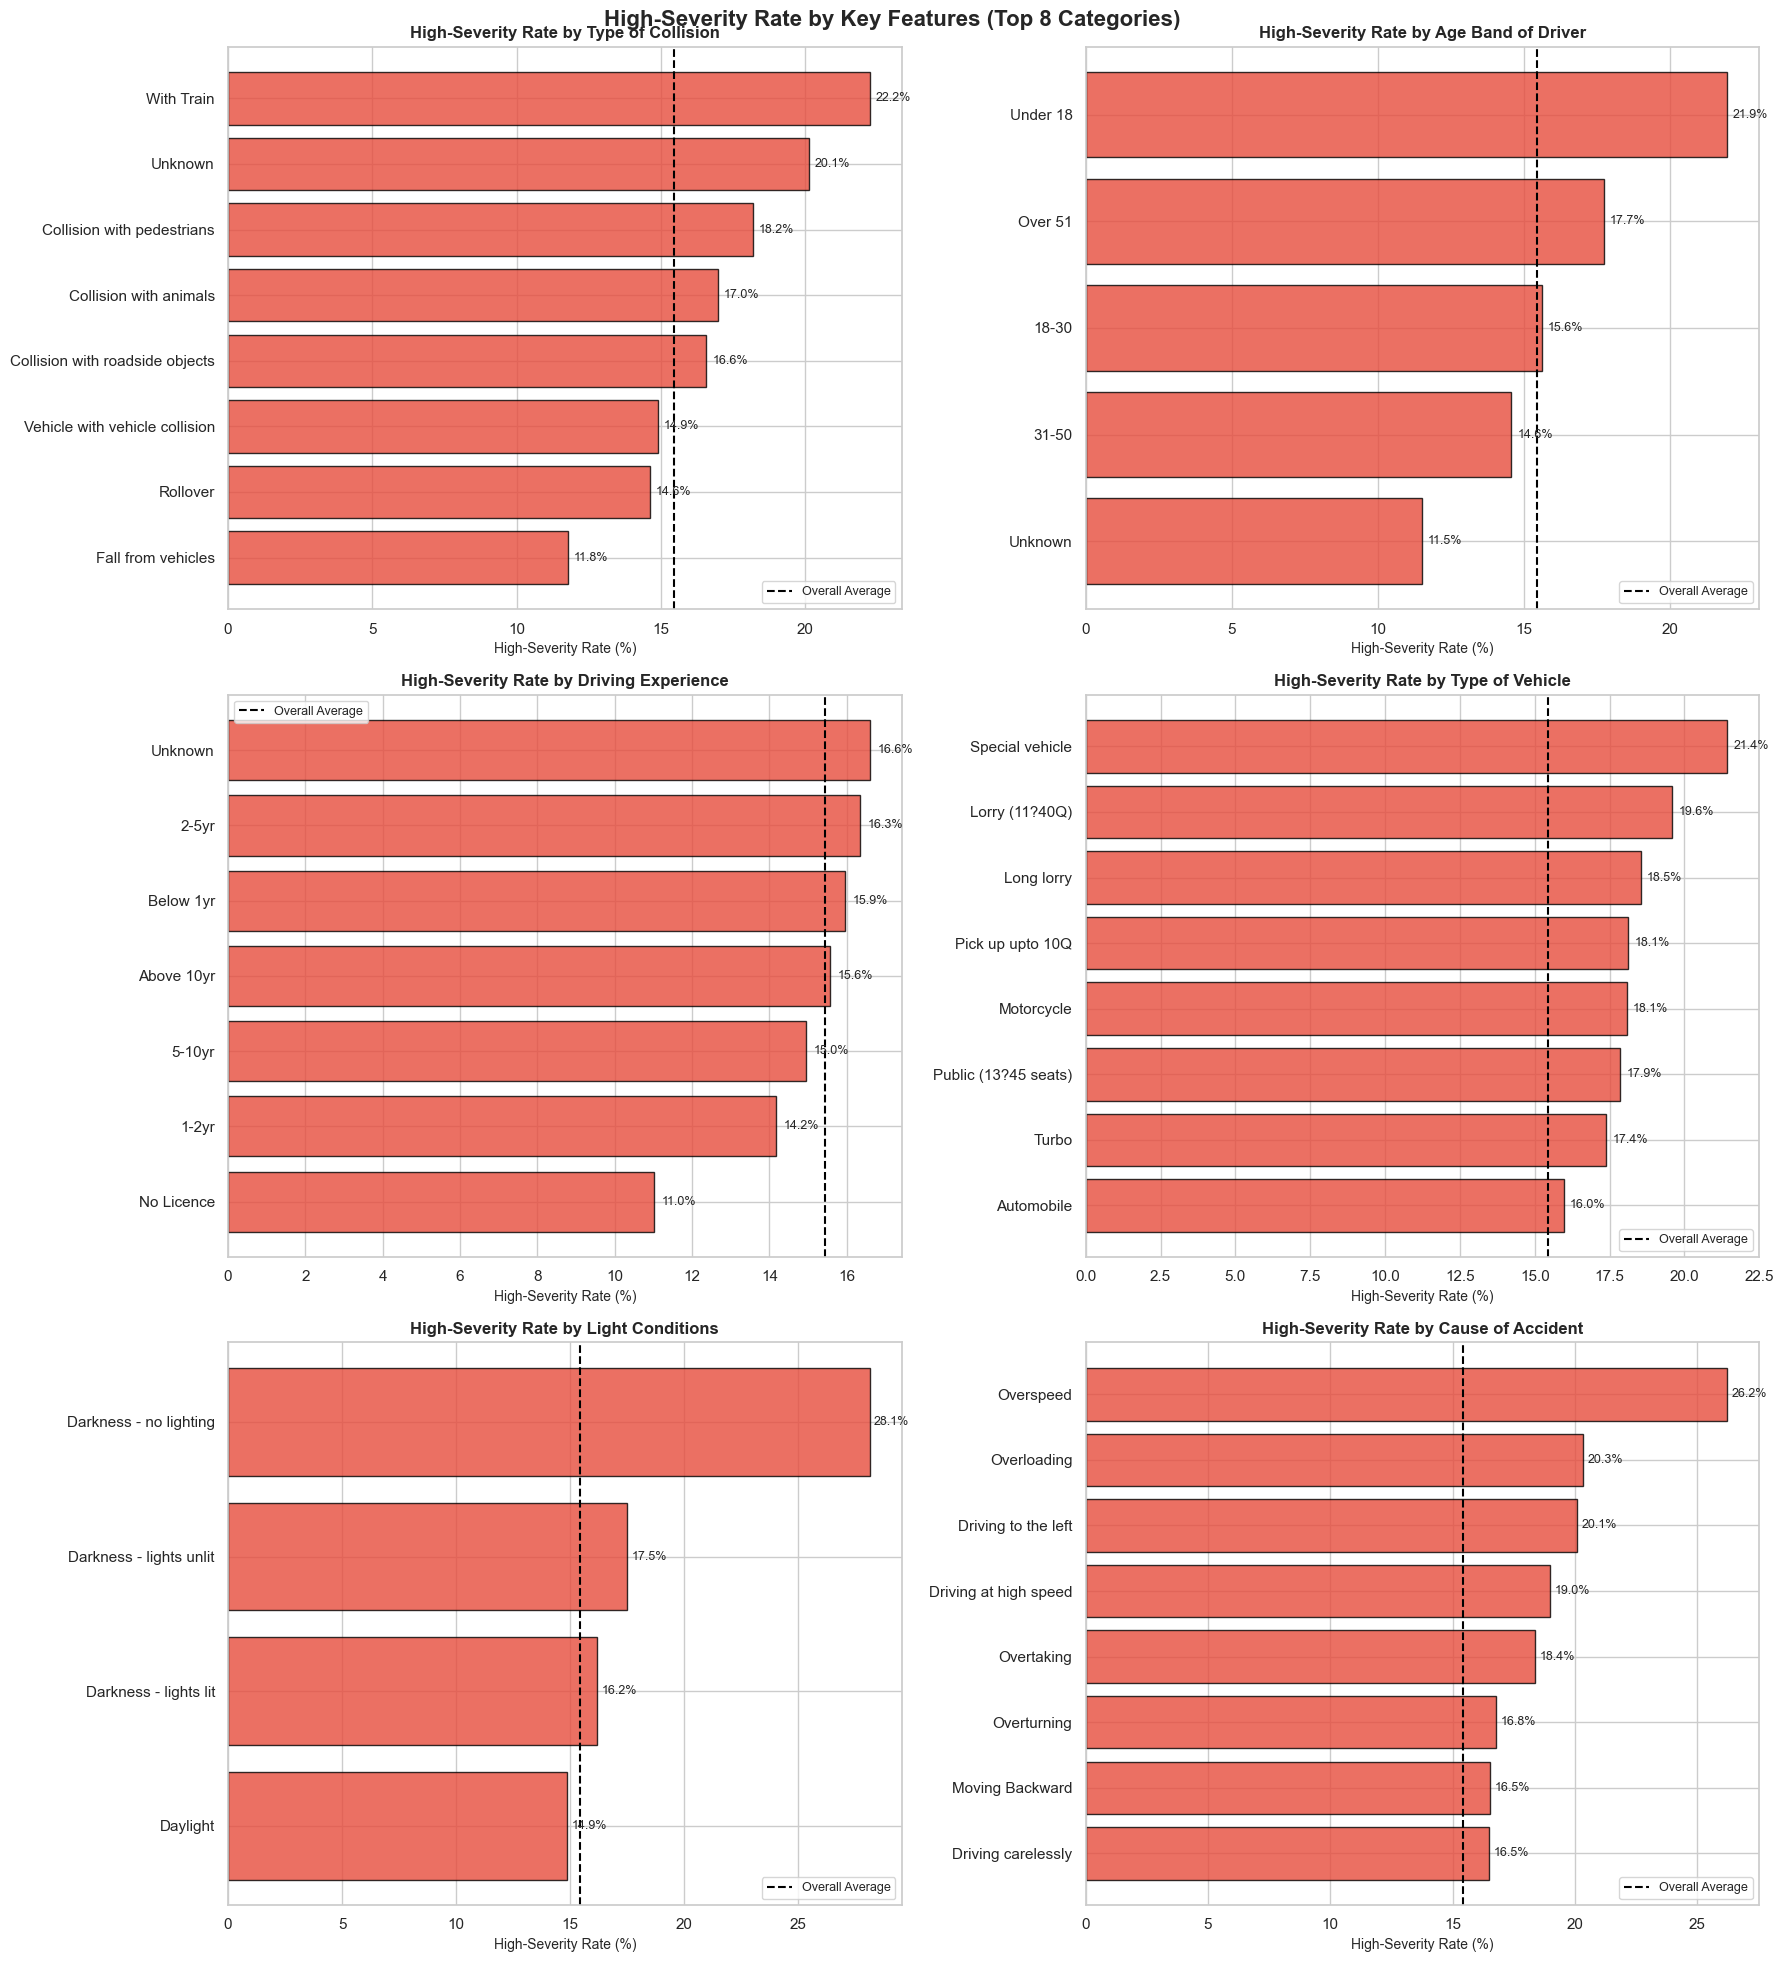

Feature severity rates chart saved successfully.


In [16]:
# ============================================================
# SECTION 10: EDA - SEVERITY BY KEY CATEGORICAL FEATURES
# Visualize High-Severity rate across important features
# Top 8 categories shown per feature for clarity
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(18, 20))

features = [
    ('Type_of_collision', 'Type of Collision'),
    ('Age_band_of_driver', 'Age Band of Driver'),
    ('Driving_experience', 'Driving Experience'),
    ('Type_of_vehicle', 'Type of Vehicle'),
    ('Light_conditions', 'Light Conditions'),
    ('Cause_of_accident', 'Cause of Accident')
]

for ax, (col, title) in zip(axes.flatten(), features):
    # Calculate High-Severity rate per category — top 8 only
    severity_rate = (df.groupby(col)['Severity_Class']
                     .mean()
                     .sort_values(ascending=False)
                     .head(8)) * 100

    bars = ax.barh(severity_rate.index, severity_rate.values,
                   color='#e74c3c', edgecolor='black', alpha=0.8)
    ax.set_title(f'High-Severity Rate by {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('High-Severity Rate (%)', fontsize=10)
    ax.axvline(x=df['Severity_Class'].mean()*100, color='black',
               linestyle='--', linewidth=1.5, label='Overall Average')
    ax.legend(fontsize=9)
    ax.invert_yaxis()

    # Add value labels
    for bar, val in zip(bars, severity_rate.values):
        ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('High-Severity Rate by Key Features (Top 8 Categories)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/severity_by_features.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature severity rates chart saved successfully.")


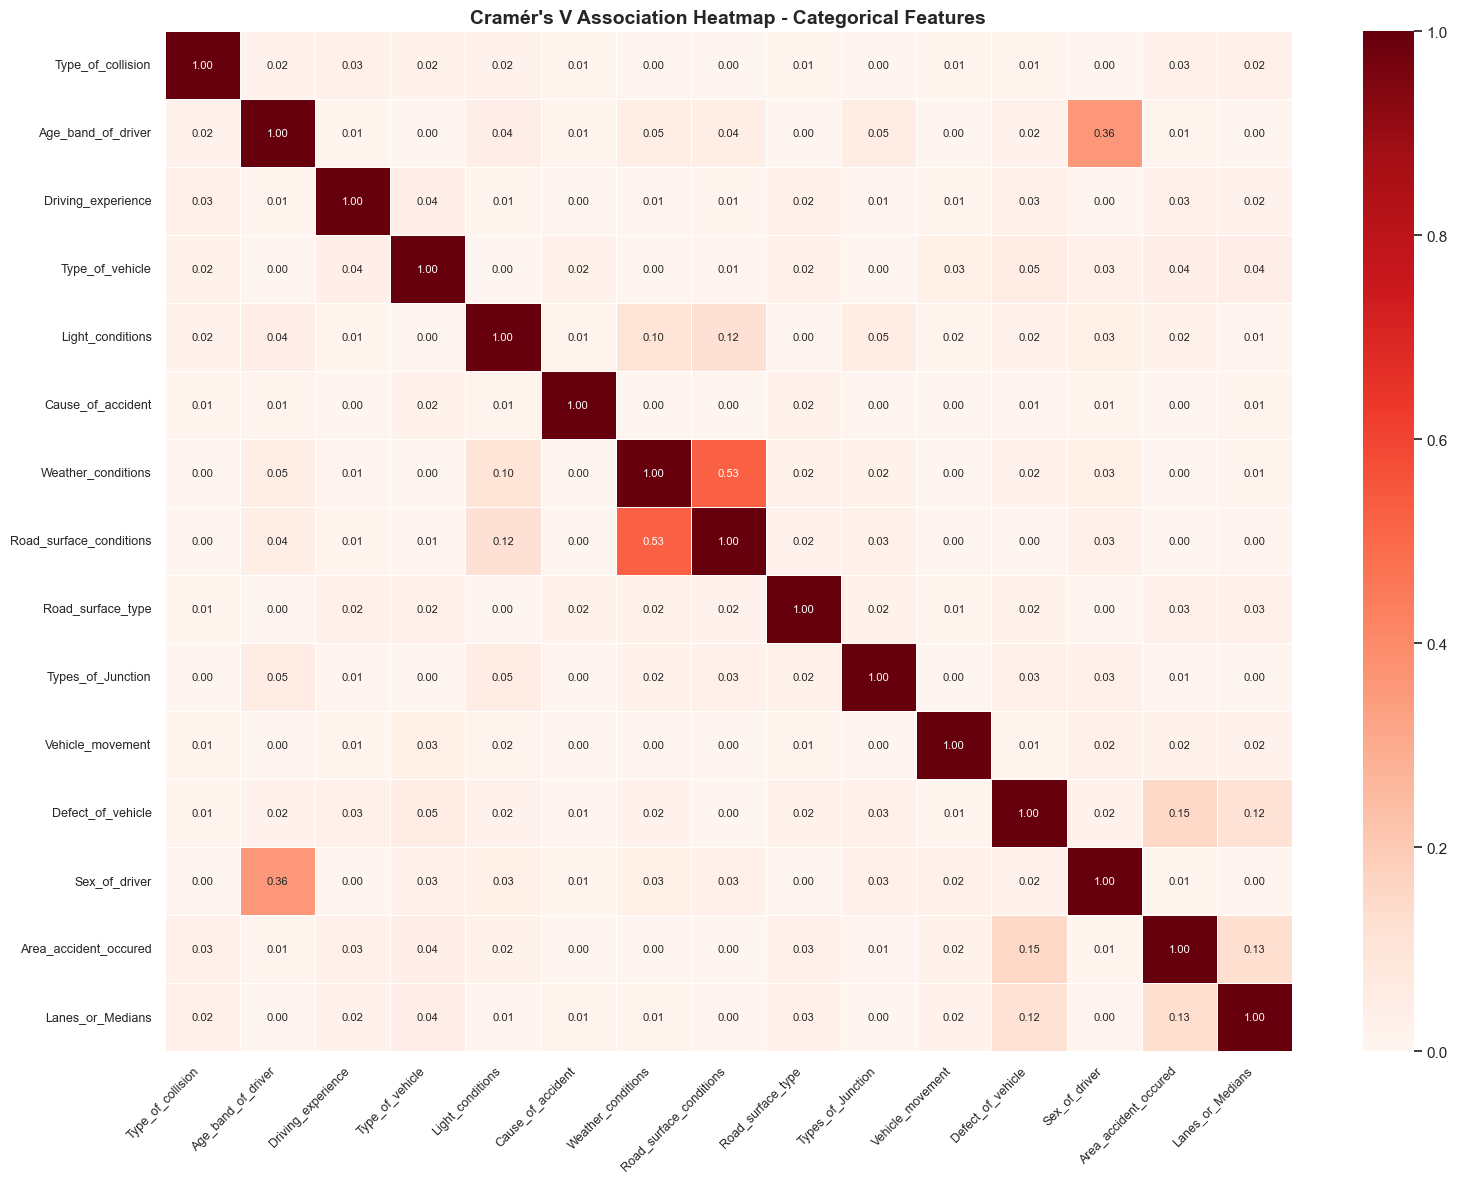

Cramér's V heatmap saved successfully.


In [17]:
# ============================================================
# SECTION 11: EDA - CRAMÉR'S V ASSOCIATION HEATMAP
# Measure association between categorical features
# and the target variable Severity_Class
# ============================================================

from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Select categorical features only
cat_features = [
    'Type_of_collision', 'Age_band_of_driver', 'Driving_experience',
    'Type_of_vehicle', 'Light_conditions', 'Cause_of_accident',
    'Weather_conditions', 'Road_surface_conditions', 'Road_surface_type',
    'Types_of_Junction', 'Vehicle_movement', 'Defect_of_vehicle',
    'Sex_of_driver', 'Area_accident_occured', 'Lanes_or_Medians'
]

# Compute Cramér's V matrix
cramers_matrix = pd.DataFrame(index=cat_features, columns=cat_features, dtype=float)

for col1 in cat_features:
    for col2 in cat_features:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    cramers_matrix.astype(float),
    annot=True,
    fmt='.2f',
    cmap='Reds',
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title("Cramér's V Association Heatmap - Categorical Features",
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('../figures/cramers_v_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Cramér's V heatmap saved successfully.")

In [19]:
# ============================================================
# SECTION 12: SAVE CLEANED LABELED DATASET
# Save the processed dataset ready for model training
# ============================================================

# Drop original Accident_severity column — replaced by Severity_Class
df_final = df.drop(columns=['Accident_severity'])

# Save to processed folder
output_path = '../data/processed/rta_accidents_labeled.csv'
df_final.to_csv(output_path, index=False)

print("Cleaned labeled dataset saved successfully.")
print(f"   Output path : {output_path}")
print(f"   Rows        : {df_final.shape[0]:,}")
print(f"   Columns     : {df_final.shape[1]}")
print(f"\nFeatures available for modeling:")
for col in df_final.columns.tolist():
    print(f"   - {col}")

Cleaned labeled dataset saved successfully.
   Output path : ../data/processed/rta_accidents_labeled.csv
   Rows        : 12,316
   Columns     : 32

Features available for modeling:
   - Time
   - Day_of_week
   - Age_band_of_driver
   - Sex_of_driver
   - Educational_level
   - Vehicle_driver_relation
   - Driving_experience
   - Type_of_vehicle
   - Owner_of_vehicle
   - Service_year_of_vehicle
   - Defect_of_vehicle
   - Area_accident_occured
   - Lanes_or_Medians
   - Road_allignment
   - Types_of_Junction
   - Road_surface_type
   - Road_surface_conditions
   - Light_conditions
   - Weather_conditions
   - Type_of_collision
   - Number_of_vehicles_involved
   - Number_of_casualties
   - Vehicle_movement
   - Casualty_class
   - Sex_of_casualty
   - Age_band_of_casualty
   - Casualty_severity
   - Work_of_casuality
   - Fitness_of_casuality
   - Pedestrian_movement
   - Cause_of_accident
   - Severity_Class
